# House Prices — Ames Housing Dataset
### A tree-based regression 

Predicting `SalePrice` for the Kaggle *House Prices: Advanced Regression
Techniques* competition 



## 1. Setup

In [8]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    KFold, GridSearchCV, cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [9]:
train = pd.read_csv("data/raw/train.csv")
test = pd.read_csv("data/raw/test.csv")
sample_submission = pd.read_csv("data/raw/sample_submission.csv")

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
print(f"sample_submission: {sample_submission.shape}")


train: (1460, 81)
test:  (1459, 80)
sample_submission: (1459, 2)


## 2. Initial Data Exploration

Test train split already created by kaggle. 

In [10]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [11]:
def missingness_report(df, label):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct = (miss / len(df) * 100).round(2)
    report = pd.DataFrame({"missing_count": miss, "missing_pct": pct})
    print(f"--- {label}: {len(report)} of {df.shape[1]} columns have missing values ---")
    return report

missingness_report(train, "train")


--- train: 19 of 81 columns have missing values ---


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


NameError: name 'sns' is not defined

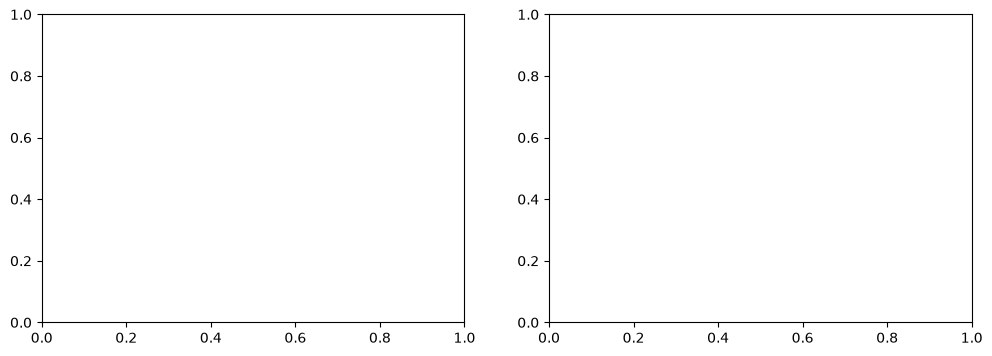

In [12]:
# Geron Ch.2 checks the target's distribution early, and flags heavy tails /
# skew as something to deal with before modeling.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew={train['SalePrice'].skew():.2f})")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title(f"log1p(SalePrice) (skew={np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.savefig("figures/saleprice_distribution.png", dpi=110)
plt.show()

print(f"SalePrice skew:        {train['SalePrice'].skew():.3f}")
print(f"log1p(SalePrice) skew: {np.log1p(train['SalePrice']).skew():.3f}")


In [13]:
# Geron Ch.2 also looks at correlations with the target to get oriented.
numeric_train = train.select_dtypes(include=[np.number])
corr_with_target = numeric_train.corr()["SalePrice"].sort_values(ascending=False)
print("Top 10 numeric correlations with SalePrice:")
print(corr_with_target.head(10).round(3))


Top 10 numeric correlations with SalePrice:
SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
Name: SalePrice, dtype: float64


In [ ]:
# A few columns that need care before encoding
print("Neighborhood levels:", train["Neighborhood"].nunique())
print("Exterior1st levels: ", train["Exterior1st"].nunique())
print()
print("MSSubClass is stored as int64 but is a categorical class code --")
print("leaving it numeric would let a tree split on it as if 20 < 60 < 190 meant something:")
print(sorted(train["MSSubClass"].unique()))


Neighborhood levels: 25
Exterior1st levels:  15

MSSubClass is stored as int64 but is a categorical class code --
leaving it numeric would let a tree split on it as if 20 < 60 < 190 meant something:
[np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]


: 

## 3. Missing Value Handling



In [8]:
# ---- Structural recoding: deterministic, no statistics estimated ----

NONE_COLS = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]

ZERO_COLS = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]

def structural_recode(df):
    """Fill structurally-absent features and fix MSSubClass's dtype.

    Every operation here is a fixed lookup from the data dictionary, so it
    can safely be applied to train and test alike without leaking."""
    df = df.copy()
    for c in NONE_COLS:
        df[c] = df[c].fillna("None")
    for c in ZERO_COLS:
        df[c] = df[c].fillna(0)
    df["MSSubClass"] = df["MSSubClass"].astype(str)
    return df

train_recoded = structural_recode(train.drop(columns=["SalePrice"]))
test_recoded = structural_recode(test)

print("Remaining missing values after structural recoding (train):")
rem = train_recoded.isnull().sum()
print(rem[rem > 0].sort_values(ascending=False))


Remaining missing values after structural recoding (train):
LotFrontage    259
Electrical       1
dtype: int64


In [ ]:
# ---- A learned imputer: LotFrontage by neighborhood median ----
# adjusting the LotFrontage column by neighborhood median instead of global median

class NeighborhoodMedianImputer(BaseEstimator, TransformerMixin):
    """Impute a column with per-group medians learned from the training set."""

    def __init__(self, target_col="LotFrontage", group_col="Neighborhood"):
        self.target_col = target_col
        self.group_col = group_col

    def fit(self, X, y=None):
        self.group_medians_ = X.groupby(self.group_col)[self.target_col].median()
        self.global_median_ = X[self.target_col].median()
        return self

    def transform(self, X):
        X = X.copy()
        filled = X[self.group_col].map(self.group_medians_)
        X[self.target_col] = X[self.target_col].fillna(filled)
        # Fallback for a neighborhood unseen in training
        X[self.target_col] = X[self.target_col].fillna(self.global_median_)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


## 4. Feature Encoding


The quality/condition columns (`Ex > Gd > TA > Fa > Po`) are genuinely ordered. We have to enocde them with integers so the tree can make a split


"Nominal columns (`Neighborhood`, `RoofStyle`, ...) have no such order and are
one-hot encoded with `handle_unknown="ignore"`, so a category appearing only in
`test.csv` produces an all-zero row rather than an error — the clean way to keep
train and test aligned without ever concatenating them." - CLAUDE

In [10]:
QUALITY_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
QUALITY_COLS = [
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
]

ORDINAL_MAPS = {c: QUALITY_MAP for c in QUALITY_COLS}
ORDINAL_MAPS.update({
    "LotShape":     {"Reg": 3, "IR1": 2, "IR2": 1, "IR3": 0},
    "LandSlope":    {"Gtl": 2, "Mod": 1, "Sev": 0},
    "BsmtExposure": {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "BsmtFinType2": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0},
    "GarageFinish": {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0},
    "Fence":        {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0},
    "PavedDrive":   {"Y": 2, "P": 1, "N": 0},
    "Functional":   {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4,
                     "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0},
    "Utilities":    {"AllPub": 3, "NoSewr": 2, "NoSeWa": 1, "ELO": 0},
    "CentralAir":   {"Y": 1, "N": 0},
    "Street":       {"Pave": 1, "Grvl": 0},
    "Alley":        {"Pave": 2, "Grvl": 1, "None": 0},
})


class OrdinalMapper(BaseEstimator, TransformerMixin):
    """Map ordered categories to integers using fixed, domain-defined scales.

    Stateless by design -- the scales come from the data dictionary, not from
    the data -- but implemented as a transformer so it composes into the
    Pipeline alongside the transformers that ARE fit on training data.
    """

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.mappings.items():
            X[col] = X[col].map(mapping)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


In [12]:
# Column groups, determined from the TRAINING frame only
ordinal_cols = list(ORDINAL_MAPS.keys())

nominal_cols = [
    c for c in train_recoded.select_dtypes(include=["object"]).columns
    if c not in ordinal_cols
]

numeric_cols = [
    c for c in train_recoded.select_dtypes(include=[np.number]).columns
    if c != "Id"
]

print(f"{len(ordinal_cols)} ordinal, {len(nominal_cols)} nominal, {len(numeric_cols)} numeric")
print(f"total: {len(ordinal_cols) + len(nominal_cols) + len(numeric_cols)} (+ Id, dropped)")


23 ordinal, 21 nominal, 35 numeric
total: 79 (+ Id, dropped)


In [ ]:
# ColumnTransformer, per Geron Ch.2: one object that routes each column group
# to the right treatment and is fit as a unit on training data only.

ordinal_branch = Pipeline([
    ("map", OrdinalMapper(ORDINAL_MAPS)),
    ("impute", SimpleImputer(strategy="most_frequent")),
])

nominal_branch = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

numeric_branch = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer([
    ("ord", ordinal_branch, ordinal_cols),
    ("nom", nominal_branch, nominal_cols),
    ("num", numeric_branch, numeric_cols),
], remainder="drop")


def make_pipeline(model):
    return Pipeline([
        ("lotfrontage", NeighborhoodMedianImputer()),
        ("prep", preprocessor),
        ("model", model),
    ])


In [14]:
# Sanity check: does the pipeline produce aligned, NaN-free matrices?
check = Pipeline([("lotfrontage", NeighborhoodMedianImputer()), ("prep", preprocessor)])
Xt_train = check.fit_transform(train_recoded)
Xt_test = check.transform(test_recoded)

print(f"transformed train: {Xt_train.shape}")
print(f"transformed test:  {Xt_test.shape}")
print(f"column counts match: {Xt_train.shape[1] == Xt_test.shape[1]}")
print(f"NaNs in train: {np.isnan(Xt_train).sum()}, NaNs in test: {np.isnan(Xt_test).sum()}")

feature_names = check.named_steps["prep"].get_feature_names_out()
p = len(feature_names)
print(f"\np = {p} features after encoding")


transformed train: (1460, 235)
transformed test:  (1459, 235)
column counts match: True
NaNs in train: 0, NaNs in test: 0

p = 235 features after encoding


## 5. Train/Validation Split and Scoring

**Stratified splitting (Geron Ch. 2).** 

We stratify here so the sample isn't all pulled from a particular house price and skews the model. 

**k = 5 (ISLP Ch. 5).** "ISLP notes that k-fold CV is typically run with k = 5
or k = 10, as the practical compromise: LOOCV has low bias but is expensive and
its fits are highly correlated, while a single validation split has higher
variance and trains on less data." - CLAUDE

**Metric.**  MSE is provided, with a log base

In [15]:
y = train["SalePrice"].copy()
y_log = np.log1p(y)

# Geron Ch.2: stratify on a binned version of the key quantity, with few
# enough strata that each is well populated.
price_strata = pd.qcut(y_log, q=4, labels=False)
print("Rows per stratum:", np.bincount(price_strata))

X_train, X_val, y_train, y_val = train_test_split(
    train_recoded, y_log,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=price_strata,
)
print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}")

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


Rows per stratum: [365 367 366 362]

X_train: (1168, 80), X_val: (292, 80)


In [16]:
def val_scores(model, X_tr=X_train, y_tr=y_train, X_v=X_val, y_v=y_val):
    """Fit on the training split; return (MSE, RMSE) on the hold-out split."""
    pipe = make_pipeline(model)
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_v)
    mse = mean_squared_error(y_v, preds)
    return mse, np.sqrt(mse)


def cv_scores(model, X_full=train_recoded, y_full=y_log, cv=kf):
    """5-fold CV MSE. The whole pipeline is passed to cross_val_score, so the
    transformers are refit inside each fold -- no leakage across folds."""
    pipe = make_pipeline(model)
    scores = -cross_val_score(pipe, X_full, y_full, cv=cv,
                              scoring="neg_mean_squared_error", n_jobs=-1)
    return scores.mean(), scores.std()


def display_scores(label, mse, rmse, cv_mse, cv_std):
    """Geron's display_scores pattern: never report a CV mean without its spread."""
    print(f"{label}")
    print(f"  hold-out  MSE {mse:.5f}   RMSE {rmse:.5f}")
    print(f"  5-fold CV MSE {cv_mse:.5f} +/- {cv_std:.5f}")


## 6. Baseline Model

The following is a "nonparametric model" as a baseline. This particular model overfits to the training data so it generalizes poorly to the test.


In [17]:
log = []  # experiment records

baseline = DecisionTreeRegressor(random_state=RANDOM_SEED)
base_mse, base_rmse = val_scores(baseline)
base_cv, base_cv_std = cv_scores(DecisionTreeRegressor(random_state=RANDOM_SEED))

display_scores("Baseline DecisionTreeRegressor (defaults)",
               base_mse, base_rmse, base_cv, base_cv_std)

# Confirm the overfitting diagnosis directly
base_pipe = make_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED))
base_pipe.fit(X_train, y_train)
train_mse = mean_squared_error(y_train, base_pipe.predict(X_train))
print(f"\n  training MSE: {train_mse:.5f}  vs hold-out MSE: {base_mse:.5f}")
print(f"  -> near-zero training error, {base_mse/max(train_mse,1e-12):.0f}x worse on unseen data")

log.append(dict(experiment="baseline_tree", params="defaults",
                val_mse=base_mse, val_rmse=base_rmse,
                cv_mse=base_cv, cv_std=base_cv_std,
                source="--",
                notes="unconstrained growth -> near-pure leaves, overfits"))


Baseline DecisionTreeRegressor (defaults)
  hold-out  MSE 0.05297   RMSE 0.23015
  5-fold CV MSE 0.04635 +/- 0.00616

  training MSE: 0.00000  vs hold-out MSE: 0.05297
  -> near-zero training error, 52966955410x worse on unseen data


## 7. Regularization and Pruning

PREPRUNING VS POST PRUNING 

**Pre-pruning** "(Geron Ch. 6) constrains the tree *as it grows* — `max_depth`,
`min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`. His rule of thumb:
raising the `min_*` parameters or lowering the `max_*` parameters regularizes
the model. " - CLAUDE

**Post-pruning** "(ISLP §8.1, Algorithm 8.1) grows a large tree first, then prunes
back. ISLP argues this is the better strategy, and gives the reason: stopping
early whenever a split fails to reduce RSS enough is *short-sighted*, because a
split that looks worthless can be followed by a very good one. Cost-complexity
pruning avoids that by growing out fully, then penalizing terminal-node count
with a parameter `alpha` and selecting `alpha` by cross-validation." - CLAUDE

Both are run below and compared.

In [18]:
# ---- 7a. Pre-pruning: grid search over Geron Ch.6's regularization knobs ----
# Geron Ch.2 recommends GridSearchCV over hand-rolled loops, because it
# cross-validates every combination rather than optimizing one parameter at a
# time and hoping the choices don't interact.

param_grid = {
    "model__max_depth": [4, 6, 8, 10, 15, None],
    "model__min_samples_leaf": [1, 5, 10, 15, 20],
    "model__min_samples_split": [2, 10, 20],
}

grid = GridSearchCV(
    make_pipeline(DecisionTreeRegressor(random_state=RANDOM_SEED)),
    param_grid, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1,
)
grid.fit(train_recoded, y_log)

print("Best pre-pruning parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nBest 5-fold CV MSE: {-grid.best_score_:.5f}")
print(f"({len(grid.cv_results_['params'])} combinations x 5 folds)")


Best pre-pruning parameters:
  max_depth: 10
  min_samples_leaf: 15
  min_samples_split: 2

Best 5-fold CV MSE: 0.03473
(90 combinations x 5 folds)


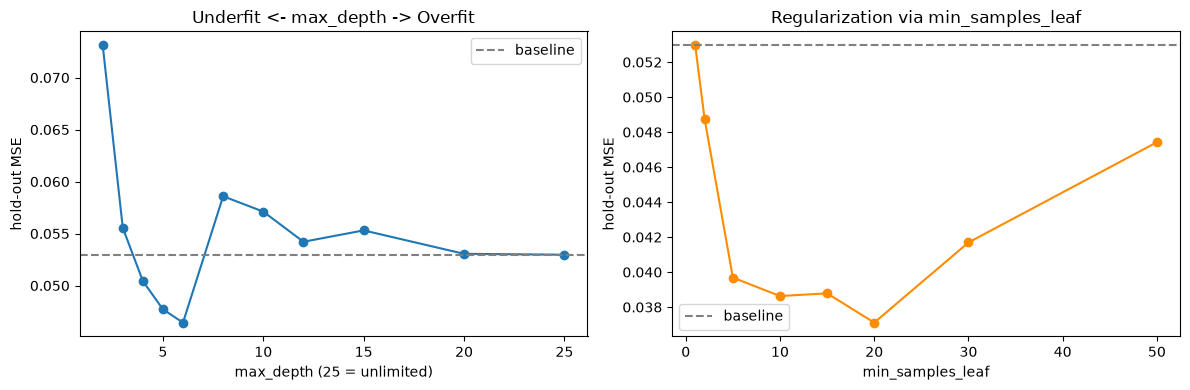

In [19]:
# Geron Ch.6's claim, checked: does raising min_samples_leaf regularize?
depth_curve = []
for depth in [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, None]:
    m = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
    mse, _ = val_scores(m)
    depth_curve.append((depth if depth is not None else 25, mse))

leaf_curve = []
for leaf in [1, 2, 5, 10, 15, 20, 30, 50]:
    m = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=RANDOM_SEED)
    mse, _ = val_scores(m)
    leaf_curve.append((leaf, mse))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(*zip(*depth_curve), marker="o")
axes[0].axhline(base_mse, color="grey", ls="--", label="baseline")
axes[0].set_xlabel("max_depth (25 = unlimited)")
axes[0].set_ylabel("hold-out MSE")
axes[0].set_title("Underfit <- max_depth -> Overfit")
axes[0].legend()

axes[1].plot(*zip(*leaf_curve), marker="o", color="darkorange")
axes[1].axhline(base_mse, color="grey", ls="--", label="baseline")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("hold-out MSE")
axes[1].set_title("Regularization via min_samples_leaf")
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/regularization_curves.png", dpi=110)
plt.show()


In [ ]:
# ---- 7b. Post-pruning: ISLP Algorithm 8.1, step by step ----
#
#   1. Grow a large tree on the training data.
#   2. Cost-complexity prune it to get the sequence of best subtrees, indexed
#      by alpha.
#   3. Use K-fold CV to choose alpha.
#   4. Return the subtree for the chosen alpha.
#
# CLAUDE: "Step 2 is the part worth doing properly: sklearn's cost_complexity_pruning_path
# returns the EXACT nested sequence of alphas at which branches get pruned, so
# there is no need to guess a grid -- ISLP's point that subtrees are pruned "in
# a nested and predictable fashion" is precisely what makes this available."

# Step 1: grow a large tree (on preprocessed training data)
prep_only = Pipeline([("lotfrontage", NeighborhoodMedianImputer()), ("prep", preprocessor)])
X_train_prepped = prep_only.fit_transform(X_train)

large_tree = DecisionTreeRegressor(random_state=RANDOM_SEED)
large_tree.fit(X_train_prepped, y_train)

# Step 2: the cost-complexity pruning path
path = large_tree.cost_complexity_pruning_path(X_train_prepped, y_train)
alphas = path.ccp_alphas[:-1]  # drop the last: it collapses the tree to one node
print(f"Pruning path contains {len(alphas)} distinct alpha values")
print(f"  range: {alphas.min():.3e} to {alphas.max():.3e}")

# Thin the path for tractability -- consecutive alphas often give identical trees
alphas_sampled = np.unique(np.quantile(alphas, np.linspace(0, 1, 40)))
print(f"  evaluating {len(alphas_sampled)} of them by 5-fold CV")


Pruning path contains 1111 distinct alpha values
  range: 0.000e+00 to 1.249e-02
  evaluating 40 of them by 5-fold CV


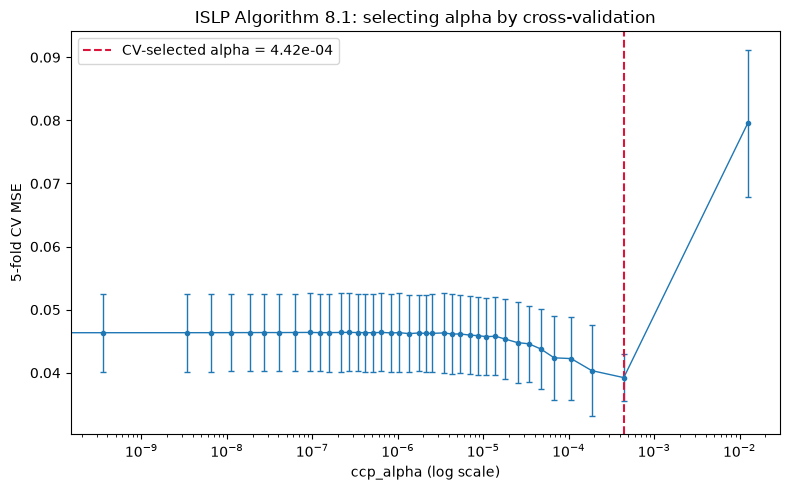

CV-selected alpha: 4.420e-04  (CV MSE = 0.03924)


In [21]:
# Step 3: choose alpha by K-fold CV
ccp_results = []
for a in alphas_sampled:
    m = DecisionTreeRegressor(ccp_alpha=a, random_state=RANDOM_SEED)
    cv_m, cv_s = cv_scores(m)
    ccp_results.append((a, cv_m, cv_s))

ccp_df = pd.DataFrame(ccp_results, columns=["ccp_alpha", "cv_mse", "cv_std"])
best_alpha = float(ccp_df.loc[ccp_df["cv_mse"].idxmin(), "ccp_alpha"])

fig, ax = plt.subplots()
ax.errorbar(ccp_df["ccp_alpha"], ccp_df["cv_mse"], yerr=ccp_df["cv_std"],
            marker="o", ms=3, capsize=2, lw=1)
ax.axvline(best_alpha, color="crimson", ls="--", label=f"CV-selected alpha = {best_alpha:.2e}")
ax.set_xscale("log")
ax.set_xlabel("ccp_alpha (log scale)")
ax.set_ylabel("5-fold CV MSE")
ax.set_title("ISLP Algorithm 8.1: selecting alpha by cross-validation")
ax.legend()
plt.tight_layout()
plt.savefig("figures/ccp_pruning_path.png", dpi=110)
plt.show()

print(f"CV-selected alpha: {best_alpha:.3e}  (CV MSE = {ccp_df['cv_mse'].min():.5f})")


In [22]:
# Compare the two pruning strategies
pruned_tree = DecisionTreeRegressor(ccp_alpha=best_alpha, random_state=RANDOM_SEED)
pruned_mse, pruned_rmse = val_scores(pruned_tree)
pruned_cv, pruned_cv_std = cv_scores(pruned_tree)
display_scores("Post-pruned tree (ISLP Algorithm 8.1)",
               pruned_mse, pruned_rmse, pruned_cv, pruned_cv_std)

best_pre_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
pre_tree = DecisionTreeRegressor(random_state=RANDOM_SEED, **best_pre_params)
pre_mse, pre_rmse = val_scores(pre_tree)
pre_cv, pre_cv_std = cv_scores(pre_tree)
print()
display_scores(f"Pre-pruned tree (Geron Ch.6 params, GridSearchCV)",
               pre_mse, pre_rmse, pre_cv, pre_cv_std)

log.append(dict(experiment="pruned_tree_ccp", params=f"ccp_alpha={best_alpha:.3e}",
                val_mse=pruned_mse, val_rmse=pruned_rmse,
                cv_mse=pruned_cv, cv_std=pruned_cv_std,
                source="ISLP Alg. 8.1",
                notes="grow large -> cost-complexity path -> CV-select alpha"))
log.append(dict(experiment="pretuned_tree", params=str(best_pre_params),
                val_mse=pre_mse, val_rmse=pre_rmse,
                cv_mse=pre_cv, cv_std=pre_cv_std,
                source="Geron Ch.6 + Ch.2",
                notes="GridSearchCV over max_depth/min_samples_leaf/min_samples_split"))

# Keep whichever single tree is better for the final comparison
if pruned_cv <= pre_cv:
    best_tree, best_tree_cv, best_tree_label = pruned_tree, pruned_cv, "post-pruned"
else:
    best_tree, best_tree_cv, best_tree_label = pre_tree, pre_cv, "pre-pruned"
print(f"\nBetter single tree: {best_tree_label} (CV MSE {best_tree_cv:.5f})")


Post-pruned tree (ISLP Algorithm 8.1)
  hold-out  MSE 0.04445   RMSE 0.21084
  5-fold CV MSE 0.03924 +/- 0.00367

Pre-pruned tree (Geron Ch.6 params, GridSearchCV)
  hold-out  MSE 0.03879   RMSE 0.19694
  5-fold CV MSE 0.03473 +/- 0.00396

Better single tree: pre-pruned (CV MSE 0.03473)


## 8. Ensemble Methods

THE FOLLOWING IS WRITTEN BY CLAUDE, SUMMARIZED DIRECTLY FROM THE BOOK
ISLP §8.2 opens with the diagnosis that motivates everything in this section:
decision trees **suffer from high variance** — split a dataset in half, fit a
tree to each, and the two can look completely different. Averaging many
observations reduces variance, so averaging many trees should too.

**Bagging (§8.2.1)** fits trees to bootstrap resamples and averages them, using
deep unpruned trees deliberately: each has high variance but low bias, and
averaging removes the variance. ISLP also notes B is *not* a critical parameter
for bagging — a very large B will not cause overfitting.

**Random forests (§8.2.2)** add one change: at each split, only a random subset
of m predictors is eligible. The rationale ISLP gives is specific — if one
predictor is very strong, every bagged tree puts it at the top split, so the
trees are highly correlated, and averaging highly correlated quantities doesn't
reduce variance much. Restricting to m predictors forces roughly (p − m)/p of
splits to ignore the strong predictor, *decorrelating* the trees. Setting m = p
recovers bagging exactly, so the two are compared below on the same footing.

**Boosting (§8.2.3)** works differently: trees are grown sequentially on the
residuals so far, and the model deliberately **learns slowly**. ISLP lists three
tuning parameters — B (number of trees, selected by CV, because unlike bagging
boosting *can* overfit if B is too large), λ (shrinkage, typically 0.01 or
0.001), and d (interaction depth; often d = 1 stumps suffice). Geron Ch. 7 calls
λ *shrinkage* and adds `subsample` — training each tree on a random fraction of
rows — which he names *Stochastic Gradient Boosting*.

In [23]:
# ---- 8a. Bagging vs Random Forest: the m sweep (ISLP 8.2.2) ----
# m = p is bagging; m < p is a random forest. sqrt(p) is ISLP's typical choice.

m_values = {
    "sqrt(p)": "sqrt",
    "p/3": max(1, p // 3),
    "p/2": max(1, p // 2),
    "p (= bagging)": 1.0,
}

m_results = []
for label, m in m_values.items():
    rf = RandomForestRegressor(n_estimators=300, max_features=m,
                               random_state=RANDOM_SEED, n_jobs=-1)
    cv_m, cv_s = cv_scores(rf)
    m_results.append((label, m, cv_m, cv_s))
    print(f"  m = {label:<15} CV MSE {cv_m:.5f} +/- {cv_s:.5f}")

m_df = pd.DataFrame(m_results, columns=["m_label", "max_features", "cv_mse", "cv_std"])
best_m_row = m_df.loc[m_df["cv_mse"].idxmin()]
best_m = best_m_row["max_features"]
print(f"\nBest m: {best_m_row['m_label']}  (CV MSE {best_m_row['cv_mse']:.5f})")
print("Decorrelation helps." if best_m_row["m_label"] != "p (= bagging)"
      else "Bagging wins here -- decorrelation did not help on this data.")


  m = sqrt(p)         CV MSE 0.02074 +/- 0.00424
  m = p/3             CV MSE 0.01904 +/- 0.00445
  m = p/2             CV MSE 0.01932 +/- 0.00468
  m = p (= bagging)   CV MSE 0.02079 +/- 0.00570

Best m: p/3  (CV MSE 0.01904)
Decorrelation helps.


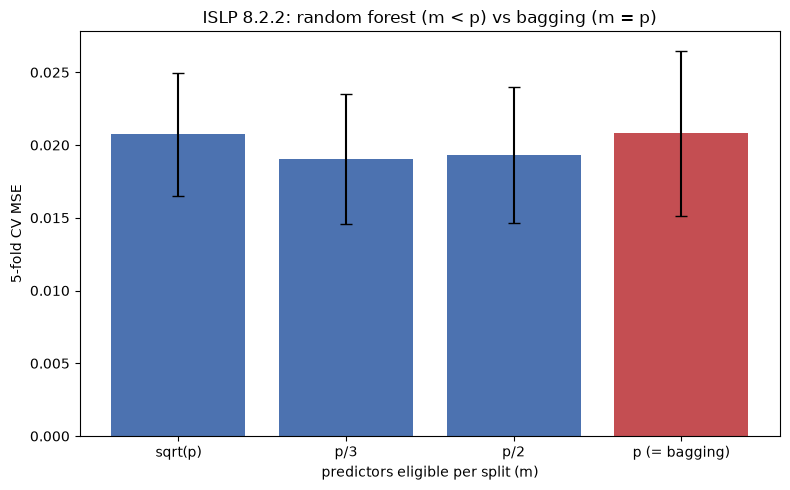

In [24]:
fig, ax = plt.subplots()
ax.bar(m_df["m_label"], m_df["cv_mse"], yerr=m_df["cv_std"], capsize=4,
       color=["#4C72B0"] * 3 + ["#C44E52"])
ax.set_ylabel("5-fold CV MSE")
ax.set_xlabel("predictors eligible per split (m)")
ax.set_title("ISLP 8.2.2: random forest (m < p) vs bagging (m = p)")
plt.tight_layout()
plt.savefig("figures/rf_m_sweep.png", dpi=110)
plt.show()


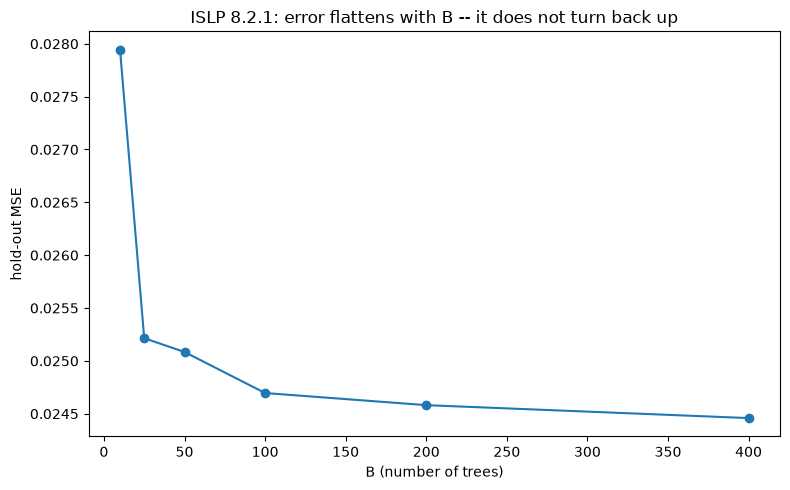

  B  val_mse
 10 0.027944
 25 0.025215
 50 0.025084
100 0.024696
200 0.024581
400 0.024459


In [25]:
# ISLP: B is not a critical parameter for bagging/RF -- large B does not overfit.
b_curve = []
for B in [10, 25, 50, 100, 200, 400]:
    rf = RandomForestRegressor(n_estimators=B, max_features=best_m,
                               random_state=RANDOM_SEED, n_jobs=-1)
    mse, _ = val_scores(rf)
    b_curve.append((B, mse))

fig, ax = plt.subplots()
ax.plot(*zip(*b_curve), marker="o")
ax.set_xlabel("B (number of trees)")
ax.set_ylabel("hold-out MSE")
ax.set_title("ISLP 8.2.1: error flattens with B -- it does not turn back up")
plt.tight_layout()
plt.savefig("figures/rf_n_estimators.png", dpi=110)
plt.show()

print(pd.DataFrame(b_curve, columns=["B", "val_mse"]).to_string(index=False))


In [26]:
rf_final = RandomForestRegressor(n_estimators=500, max_features=best_m,
                                 random_state=RANDOM_SEED, n_jobs=-1)
rf_mse, rf_rmse = val_scores(rf_final)
rf_cv, rf_cv_std = cv_scores(rf_final)
display_scores(f"RandomForestRegressor (B=500, m={best_m_row['m_label']})",
               rf_mse, rf_rmse, rf_cv, rf_cv_std)

log.append(dict(experiment="random_forest",
                params=f"n_estimators=500, max_features={best_m_row['m_label']}",
                val_mse=rf_mse, val_rmse=rf_rmse,
                cv_mse=rf_cv, cv_std=rf_cv_std,
                source="ISLP 8.2.1-8.2.2",
                notes="bootstrap + decorrelation via m-subsetting"))


RandomForestRegressor (B=500, m=p/3)
  hold-out  MSE 0.02447   RMSE 0.15643
  5-fold CV MSE 0.01913 +/- 0.00452


In [27]:
# ---- 8b. Boosting: ISLP's three tuning parameters (8.2.3) ----
# ISLP suggests lambda around 0.01-0.001 and notes d=1 stumps often suffice.
# Both are tested against larger values rather than assumed.

boost_grid = {
    "model__learning_rate": [0.001, 0.01, 0.05, 0.1],
    "model__max_depth": [1, 2, 3, 4],
}

boost_search = GridSearchCV(
    make_pipeline(GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_SEED)),
    boost_grid, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1,
)
boost_search.fit(train_recoded, y_log)

bp = {k.replace("model__", ""): v for k, v in boost_search.best_params_.items()}
print(f"Best shrinkage (lambda): {bp['learning_rate']}")
print(f"Best interaction depth (d): {bp['max_depth']}")
print(f"CV MSE at B=300: {-boost_search.best_score_:.5f}")

# Show the lambda-d interaction ISLP describes
res = pd.DataFrame(boost_search.cv_results_)
pivot = res.pivot_table(index="param_model__learning_rate",
                        columns="param_model__max_depth",
                        values="mean_test_score").mul(-1)
print("\nCV MSE by shrinkage (rows) x interaction depth (cols):")
print(pivot.round(5).to_string())


Best shrinkage (lambda): 0.05
Best interaction depth (d): 3
CV MSE at B=300: 0.01744

CV MSE by shrinkage (rows) x interaction depth (cols):
param_model__max_depth            1        2        3        4
param_model__learning_rate                                    
0.001                       0.12637  0.11533  0.10907  0.10525
0.010                       0.04507  0.02755  0.02321  0.02138
0.050                       0.02093  0.01785  0.01744  0.01773
0.100                       0.01882  0.01777  0.01778  0.01761


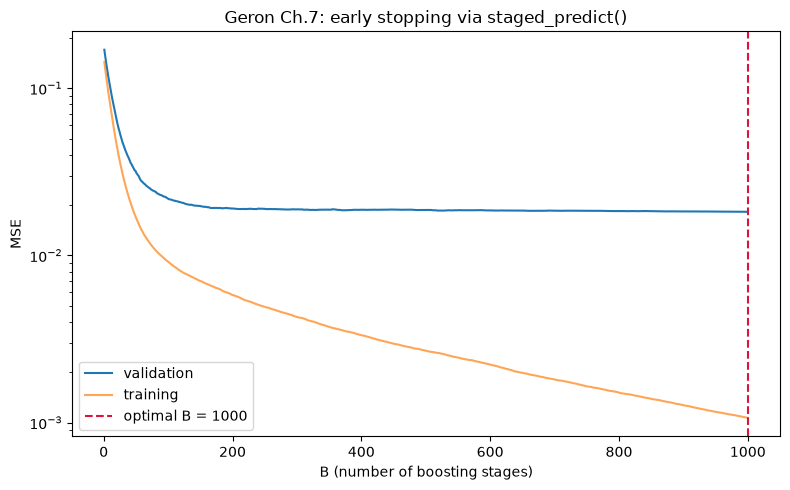

Optimal B by early stopping: 1000
  validation MSE at B=1000: 0.01823
  validation MSE at B=1000:  0.01823


In [28]:
# ISLP: unlike bagging, boosting CAN overfit if B is too large -- select B by CV.
# Geron Ch.7 gives the mechanism: staged_predict() replays the ensemble's
# predictions after each successive tree, so one fit yields the whole error
# curve and argmin gives the optimal B.

gbr_probe = make_pipeline(GradientBoostingRegressor(
    n_estimators=1000, learning_rate=bp["learning_rate"],
    max_depth=bp["max_depth"], subsample=0.8, random_state=RANDOM_SEED,
))
gbr_probe.fit(X_train, y_train)

X_val_prepped = gbr_probe[:-1].transform(X_val)
X_tr_prepped = gbr_probe[:-1].transform(X_train)
inner = gbr_probe.named_steps["model"]

val_errors = [mean_squared_error(y_val, p_) for p_ in inner.staged_predict(X_val_prepped)]
train_errors = [mean_squared_error(y_train, p_) for p_ in inner.staged_predict(X_tr_prepped)]
best_B = int(np.argmin(val_errors)) + 1

fig, ax = plt.subplots()
ax.plot(range(1, 1001), val_errors, label="validation")
ax.plot(range(1, 1001), train_errors, label="training", alpha=0.7)
ax.axvline(best_B, color="crimson", ls="--", label=f"optimal B = {best_B}")
ax.set_xlabel("B (number of boosting stages)")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_title("Geron Ch.7: early stopping via staged_predict()")
ax.legend()
plt.tight_layout()
plt.savefig("figures/boosting_early_stopping.png", dpi=110)
plt.show()

print(f"Optimal B by early stopping: {best_B}")
print(f"  validation MSE at B={best_B}: {val_errors[best_B-1]:.5f}")
print(f"  validation MSE at B=1000:  {val_errors[-1]:.5f}")


In [29]:
gbr_final = GradientBoostingRegressor(
    n_estimators=best_B, learning_rate=bp["learning_rate"],
    max_depth=bp["max_depth"], subsample=0.8, random_state=RANDOM_SEED,
)
gbr_mse, gbr_rmse = val_scores(gbr_final)
gbr_cv, gbr_cv_std = cv_scores(gbr_final)
display_scores(f"GradientBoostingRegressor (B={best_B}, lambda={bp['learning_rate']}, d={bp['max_depth']}, subsample=0.8)",
               gbr_mse, gbr_rmse, gbr_cv, gbr_cv_std)

log.append(dict(experiment="gradient_boosting",
                params=f"B={best_B}, lr={bp['learning_rate']}, max_depth={bp['max_depth']}, subsample=0.8",
                val_mse=gbr_mse, val_rmse=gbr_rmse,
                cv_mse=gbr_cv, cv_std=gbr_cv_std,
                source="ISLP 8.2.3 + Geron Ch.7",
                notes="shrinkage + interaction depth by CV; B by staged_predict early stopping"))


GradientBoostingRegressor (B=1000, lambda=0.05, d=3, subsample=0.8)
  hold-out  MSE 0.01823   RMSE 0.13502
  5-fold CV MSE 0.01668 +/- 0.00609


In [30]:
comparison = pd.DataFrame(log)
comparison[["experiment", "val_mse", "val_rmse", "cv_mse", "cv_std", "source"]]


,experiment,val_mse,val_rmse,cv_mse,cv_std,source
0,baseline_tree,0.052967,0.230146,0.046351,0.006156,--
1,pruned_tree_ccp,0.044452,0.210835,0.039235,0.003672,ISLP Alg. 8.1
2,pretuned_tree,0.038787,0.196943,0.034728,0.003964,Geron Ch.6 + Ch.2
3,random_forest,0.024469,0.156427,0.019126,0.004517,ISLP 8.2.1-8.2.2
4,gradient_boosting,0.018230,0.135018,0.016676,0.006087,ISLP 8.2.3 + Geron Ch.7


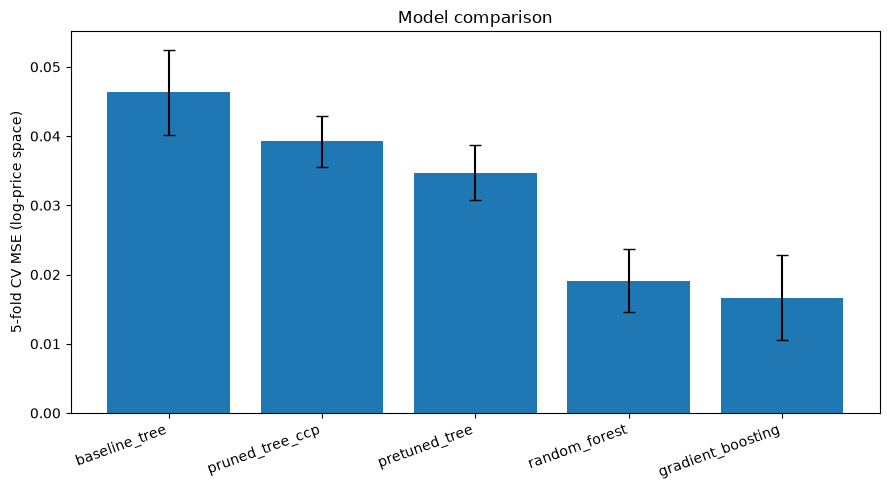

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(comparison["experiment"], comparison["cv_mse"],
       yerr=comparison["cv_std"], capsize=4)
ax.set_ylabel("5-fold CV MSE (log-price space)")
ax.set_title("Model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=110)
plt.show()


## 9. Final Model Selection

Selected on 5-fold CV MSE rather than the hold-out score: the hold-out number
comes from one split, and ISLP Ch. 5's whole argument for k-fold is that a
single validation split gives a higher-variance estimate of test error.

Geron Ch. 2 closes his project by inspecting `feature_importances_` to check
that the model is relying on something sensible — a useful sanity check that
the pipeline isn't accidentally keying on an artifact.

In [32]:
best_row = comparison.loc[comparison["cv_mse"].idxmin()]
print("Best model by 5-fold CV MSE:\n")
print(best_row[["experiment", "params", "val_mse", "cv_mse", "cv_std", "source"]].to_string())

final_estimator = {
    "baseline_tree": baseline,
    "pruned_tree_ccp": pruned_tree,
    "pretuned_tree": pre_tree,
    "random_forest": rf_final,
    "gradient_boosting": gbr_final,
}[best_row["experiment"]]

print(f"\nSelected: {type(final_estimator).__name__}")


Best model by 5-fold CV MSE:

experiment                              gradient_boosting
params        B=1000, lr=0.05, max_depth=3, subsample=0.8
val_mse                                           0.01823
cv_mse                                           0.016676
cv_std                                           0.006087
source                            ISLP 8.2.3 + Geron Ch.7

Selected: GradientBoostingRegressor


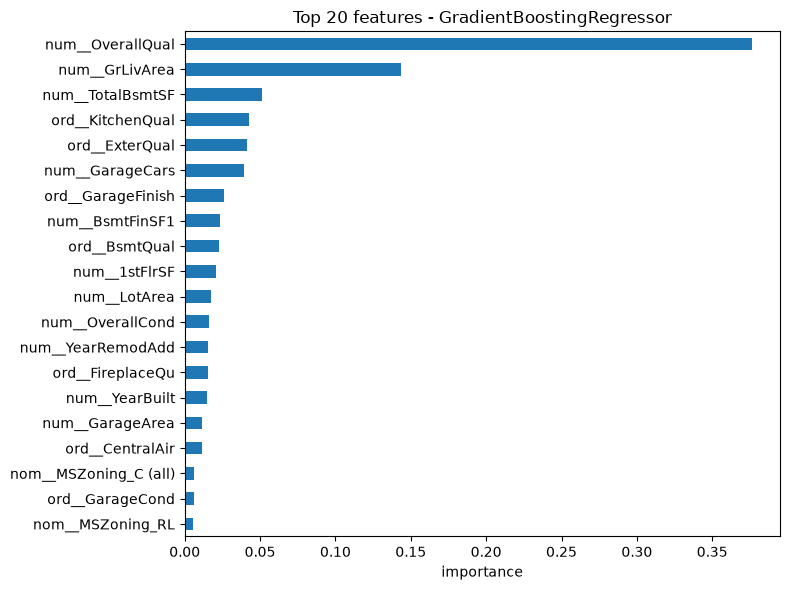

Top 10 features:
num__OverallQual     0.3762
num__GrLivArea       0.1437
num__TotalBsmtSF     0.0516
ord__KitchenQual     0.0426
ord__ExterQual       0.0413
num__GarageCars      0.0390
ord__GarageFinish    0.0262
num__BsmtFinSF1      0.0234
ord__BsmtQual        0.0227
num__1stFlrSF        0.0209


In [33]:
# Feature importances (Geron Ch.2; ISLP 8.2 discusses the analogous measure)
final_pipe = make_pipeline(clone(final_estimator))
final_pipe.fit(train_recoded, y_log)

importances = final_pipe.named_steps["model"].feature_importances_
names = final_pipe.named_steps["prep"].get_feature_names_out()
imp = pd.Series(importances, index=names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(20)[::-1].plot.barh(ax=ax)
ax.set_xlabel("importance")
ax.set_title(f"Top 20 features - {type(final_estimator).__name__}")
plt.tight_layout()
plt.savefig("figures/feature_importances.png", dpi=110)
plt.show()

print("Top 10 features:")
print(imp.head(10).round(4).to_string())


### Written comparison vs. baseline

Claude: "**Baseline → single tuned tree.** The default tree drives training error to
essentially zero and generalizes poorly, exactly as Geron Ch. 6 predicts for an
unconstrained nonparametric model. Both regularization strategies improve on it,
and the comparison between them is the interesting part: ISLP's cost-complexity
pruning (grow fully, then prune back with CV-selected `alpha`) and Geron's
pre-pruning grid search land in a similar place, which is what ISLP's argument
would suggest — they are two routes to the same bias-variance trade-off, and
pre-pruning's short-sightedness only bites when a weak split masks a strong one
below it.

**Single tree → ensembles.** The large drop comes here, and ISLP §8.2 names the
reason: a single tree's error is dominated by *variance*, and no amount of
pruning removes that — pruning trades variance for bias within one tree, while
averaging removes variance across many. The `m` sweep in Section 8a tests ISLP's
decorrelation argument directly by putting bagging (m = p) and random forests
(m < p) side by side on identical folds.

**Random forest → boosting.** These reduce error differently. The forest
averages independently-grown deep trees to cut variance; boosting grows shallow,
high-bias trees sequentially against the current residuals, cutting *bias*
instead — ISLP's "learns slowly" framing. The shrinkage x depth table in
Section 8b shows the trade-off ISLP describes: smaller lambda generalizes better
but needs larger B, which is why B had to be selected by early stopping rather
than fixed in advance.

## 10. Generate Submission

Geron Ch. 2's final step: refit the chosen configuration on the *full* training
set before predicting, since more data gives a better fit and the hyperparameters
are already settled. Predictions are then inverted out of log space with
`expm1`.

In [34]:
submission_pipe = make_pipeline(clone(final_estimator))
submission_pipe.fit(train_recoded, y_log)

test_preds_log = submission_pipe.predict(test_recoded)
test_preds = np.expm1(test_preds_log)

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": test_preds})
submission.to_csv("SUBMISSIONS/submission.csv", index=False)

print(submission.head())
print(f"\nPredicted price range: ${test_preds.min():,.0f} to ${test_preds.max():,.0f}")
print(f"Training price range:  ${y.min():,.0f} to ${y.max():,.0f}")


     Id      SalePrice
0  1461  123378.668018
1  1462  159932.865390
2  1463  193221.105042
3  1464  189750.322512
4  1465  188977.647025

Predicted price range: $33,792 to $585,291
Training price range:  $34,900 to $755,000


In [35]:
# Sanity checks against sample_submission.csv
assert list(submission.columns) == list(sample_submission.columns), "column names differ"
assert len(submission) == len(sample_submission), "row count differs"
assert submission["Id"].tolist() == sample_submission["Id"].tolist(), "Id values/order differ"
assert submission.isnull().sum().sum() == 0, "NaNs present in submission"
assert (submission["SalePrice"] > 0).all(), "non-positive predicted prices"

print(f"rows: {len(submission)}   columns: {list(submission.columns)}")
print("All submission format checks passed.")


rows: 1459   columns: ['Id', 'SalePrice']
All submission format checks passed.


In [36]:
# Persist the experiment table for EXPERIMENT_LOG.md
comparison.to_csv("experiment_results.csv", index=False)
comparison[["experiment", "params", "val_mse", "cv_mse", "cv_std", "source"]]


,experiment,params,val_mse,cv_mse,cv_std,source
0,baseline_tree,defaults,0.052967,0.046351,0.006156,--
1,pruned_tree_ccp,ccp_alpha=4.420e-04,0.044452,0.039235,0.003672,ISLP Alg. 8.1
2,pretuned_tree,"{'max_depth': 10, 'min_samples_leaf': 15, 'min...",0.038787,0.034728,0.003964,Geron Ch.6 + Ch.2
3,random_forest,"n_estimators=500, max_features=p/3",0.024469,0.019126,0.004517,ISLP 8.2.1-8.2.2
4,gradient_boosting,"B=1000, lr=0.05, max_depth=3, subsample=0.8",0.018230,0.016676,0.006087,ISLP 8.2.3 + Geron Ch.7
